# Fashion-MNIST — Pipeline PyTorch (equivalente ao `fashion-mnist-small-model-tflite-int8.py`)

Pipeline equivalente ao script TensorFlow/Keras, com foco no **monitoramento de métricas de treino e validação** (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau e histórico de loss/accuracy), **sem a parte de quantização/TFLite**.

## Setup

In [1]:
import os
import logging
import warnings
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torch.optim as optim

from torchvision import datasets, transforms

warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
EPOCHS       = 100
BATCH_SIZE   = 64
PATIENCE_ES  = 10
PATIENCE_REDUCELR_ON_PLATEAU = 5

MODEL_PATH   = "best_model.pth"
MONITOR_MET  = "val_accuracy"
LR           = 0.01
WEIGHT_DECAY = 0.0001

VAL_SPLIT    = 0.1
NUM_CLASSES  = 10
CLASS_NAMES  = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

NUM_WORKERS  = 4

## Dataset

In [3]:
# Equivalente a: RandomRotation(0.1) + RandomZoom(0.1) + RandomTranslation(0.1) do Keras
data_augmentation = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomAffine(degrees=36, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

preprocess = transforms.ToTensor()

def get_datasets():
    train_full = datasets.FashionMNIST(root="/home/jovyan/work/Datasets", train=True, download=True, transform=None)
    test_set   = datasets.FashionMNIST(root="/home/jovyan/work/Datasets", train=False, download=True, transform=None)

    indices = np.arange(len(train_full))
    np.random.shuffle(indices)
    val_size = int(len(train_full) * VAL_SPLIT)
    val_indices, train_indices = indices[:val_size], indices[val_size:]

    # Aplica transform depois, via wrapper, para treino (aug) e val/test (só preprocess)
    train_set = Subset(datasets.FashionMNIST(root="/home/jovyan/work/Datasets", train=True, transform=data_augmentation), train_indices)
    val_set   = Subset(datasets.FashionMNIST(root="/home/jovyan/work/Datasets", train=True, transform=preprocess), val_indices)
    test_set.transform = preprocess

    return train_set, val_set, test_set

train_set, val_set, test_set = get_datasets()


g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, generator=g, persistent_workers=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True)

print(f"Treino: {len(train_set)} | Val: {len(val_set)} | Teste: {len(test_set)}")

Treino: 54000 | Val: 6000 | Teste: 10000


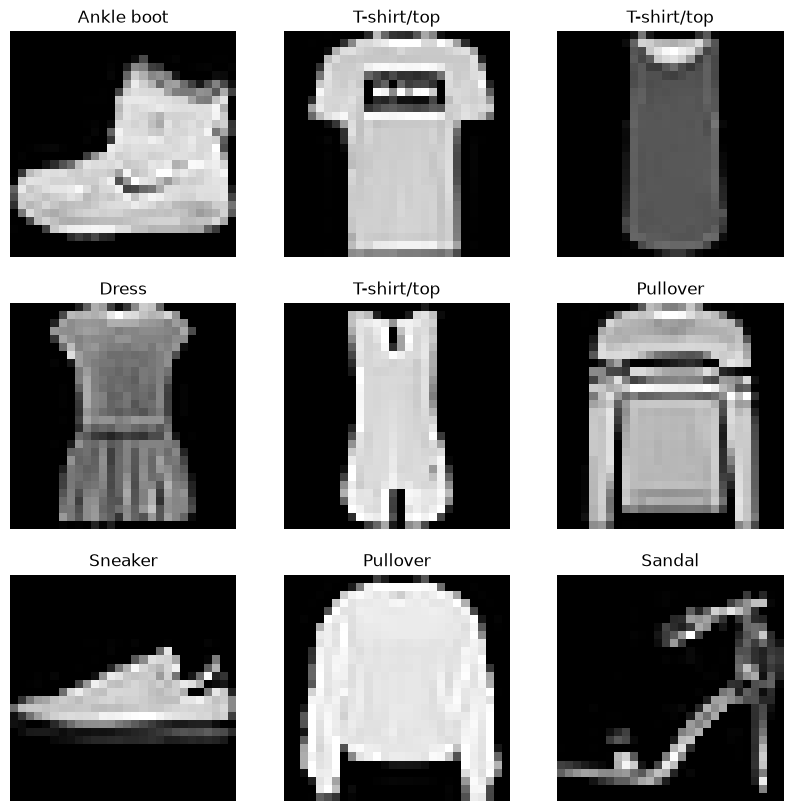

In [4]:
def plot_samples(dataset, class_names, num_samples=9):
    plt.figure(figsize=(10, 10))
    for i in range(num_samples):
        img, label = dataset[i]
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(class_names[label])
        plt.axis("off")
    plt.show()

raw_train_vis = datasets.FashionMNIST(root="/home/jovyan/work/Datasets", train=True, transform=preprocess)
plot_samples(raw_train_vis, CLASS_NAMES)

## Helpers (equivalentes aos callbacks do Keras)

In [5]:
# -------------------------------------------------------------------
# Helpers: ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, histórico
# -------------------------------------------------------------------
class History:
    def __init__(self):
        self.history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": [], "lr": []}

    def log(self, epoch, logs):
        for k, v in logs.items():
            self.history[k].append(v)
        print(
            f"Epoch {epoch+1:03d}/{EPOCHS} - "
            f"loss: {logs['loss']:.4f} - accuracy: {logs['accuracy']:.4f} - "
            f"val_loss: {logs['val_loss']:.4f} - val_accuracy: {logs['val_accuracy']:.4f} - "
            f"lr: {logs['lr']:.2e}"
        )

class ModelCheckpoint:
    """Salva o melhor modelo conforme a métrica monitorada (val_accuracy, mode='max')."""
    def __init__(self, path, monitor="val_accuracy", mode="max"):
        self.path, self.monitor, self.mode = path, monitor, mode
        self.best = -np.inf if mode == "max" else np.inf

    def __call__(self, model, logs):
        current = logs[self.monitor]
        improved = current > self.best if self.mode == "max" else current < self.best
        if improved:
            self.best = current
            torch.save(model.state_dict(), self.path)
            return True
        return False

class EarlyStopping:
    """Para o treino quando a métrica monitorada não melhora; restaura os melhores pesos."""
    def __init__(self, patience=PATIENCE_ES, monitor="val_accuracy", mode="max", min_delta=0.0):
        self.patience, self.monitor, self.mode, self.min_delta = patience, monitor, mode, min_delta
        self.best = -np.inf if mode == "max" else np.inf
        self.counter = 0
        self.best_state = None
        self.early_stop = False

    def __call__(self, model, logs):
        current = logs[self.monitor]
        if self.mode == "max":
            improved = current > self.best + self.min_delta
        else:
            improved = current < self.best - self.min_delta
        if improved:
            self.best = current
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

class ReduceLROnPlateau:
    """Reduz o LR por `factor` quando a métrica monitorada estagnar."""
    def __init__(self, optimizer, factor=0.1, patience=PATIENCE_REDUCELR_ON_PLATEAU, min_lr=1e-6, monitor="val_accuracy", mode="max"):
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode=mode, factor=factor, patience=patience, min_lr=min_lr,
        )
        self.monitor = monitor

    def __call__(self, logs):
        self.scheduler.step(logs[self.monitor])

def get_callbacks(model, optimizer):
    return (
        ModelCheckpoint(MODEL_PATH, monitor=MONITOR_MET),
        EarlyStopping(monitor=MONITOR_MET, patience=PATIENCE_ES),
        ReduceLROnPlateau(optimizer, factor=0.1, patience=PATIENCE_REDUCELR_ON_PLATEAU, min_lr=1e-6, monitor=MONITOR_MET),
    )

def plot_history(history):
    h = history.history
    epochs = range(1, len(h["loss"]) + 1)
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h["loss"], label="train")
    plt.plot(epochs, h["val_loss"], label="val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, h["accuracy"], label="train")
    plt.plot(epochs, h["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.show()

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        total_loss += loss_fn(outputs, labels).item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    loss, acc = total_loss / total, correct / total
    print(f"Acurácia final no test set: {acc:.4f}")
    return loss, acc

## Model

In [6]:
class BalancedFashionMNISTModel(nn.Module):
    """Equivalente a `create_balanced_model()` do Keras."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(24),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(24, 48, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(48),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(48, 96, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(96),
            nn.Dropout(0.3),

            nn.AdaptiveAvgPool2d(1),   # GlobalAveragePooling2D
            nn.Flatten(),
            nn.Linear(96, 64), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = BalancedFashionMNISTModel().to(device)
print(model)
print(f"Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

BalancedFashionMNISTModel(
  (net): Sequential(
    (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Dropout(p=0.3, inplace=False)
    (14): AdaptiveAvgPool2d(output_size=1)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=96, out_f

## Train

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

checkpoint_cb, earlystop_cb, reducelr_cb = get_callbacks(model, optimizer)
history = History()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        total_loss += criterion(outputs, labels).item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

print(f"\nStart training - {EPOCHS} epochs (batch size={BATCH_SIZE})")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    logs = {
        "loss": train_loss,
        "accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.log(epoch, logs)

    # ModelCheckpoint (save_best_only)
    saved = checkpoint_cb(model, logs)
    if saved:
        print(f"  -> Melhor modelo salvo em '{MODEL_PATH}' ({MONITOR_MET}={val_acc:.4f})")

    # ReduceLROnPlateau
    reducelr_cb(logs)

    # EarlyStopping
    if earlystop_cb(model, logs):
        print(f"\nEarlyStopping: sem melhora em '{MONITOR_MET}' por {PATIENCE_ES} épocas. Restaurando melhores pesos (época com {MONITOR_MET}={earlystop_cb.best:.4f}).")
        earlystop_cb.restore_best_weights(model)
        break

print("\nTreino finalizado.")


Start training - 100 epochs (batch size=64)
Epoch 001/100 - loss: 0.8525 - accuracy: 0.6765 - val_loss: 0.5370 - val_accuracy: 0.7930 - lr: 1.00e-02
  -> Melhor modelo salvo em 'best_model.pth' (val_accuracy=0.7930)
Epoch 002/100 - loss: 0.6635 - accuracy: 0.7507 - val_loss: 0.5035 - val_accuracy: 0.8127 - lr: 1.00e-02
  -> Melhor modelo salvo em 'best_model.pth' (val_accuracy=0.8127)
Epoch 003/100 - loss: 0.6182 - accuracy: 0.7713 - val_loss: 0.4671 - val_accuracy: 0.8157 - lr: 1.00e-02
  -> Melhor modelo salvo em 'best_model.pth' (val_accuracy=0.8157)
Epoch 004/100 - loss: 0.5892 - accuracy: 0.7838 - val_loss: 0.5235 - val_accuracy: 0.7955 - lr: 1.00e-02
Epoch 005/100 - loss: 0.5692 - accuracy: 0.7909 - val_loss: 0.5227 - val_accuracy: 0.8162 - lr: 1.00e-02
  -> Melhor modelo salvo em 'best_model.pth' (val_accuracy=0.8162)
Epoch 006/100 - loss: 0.5561 - accuracy: 0.7959 - val_loss: 0.3975 - val_accuracy: 0.8493 - lr: 1.00e-02
  -> Melhor modelo salvo em 'best_model.pth' (val_accurac

## Avaliação e curvas de treino

In [8]:
print("\nEvaluating on the test set")
evaluate_model(model, test_loader)
print(f"Number of classes {len(CLASS_NAMES)}")


Evaluating on the test set
Acurácia final no test set: 0.8876
Number of classes 10



Plotting training curve


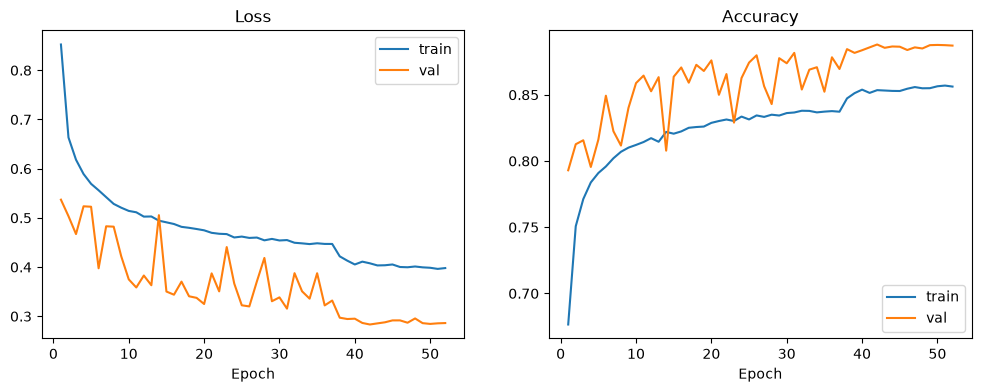

In [9]:
print("\nPlotting training curve")
plot_history(history)

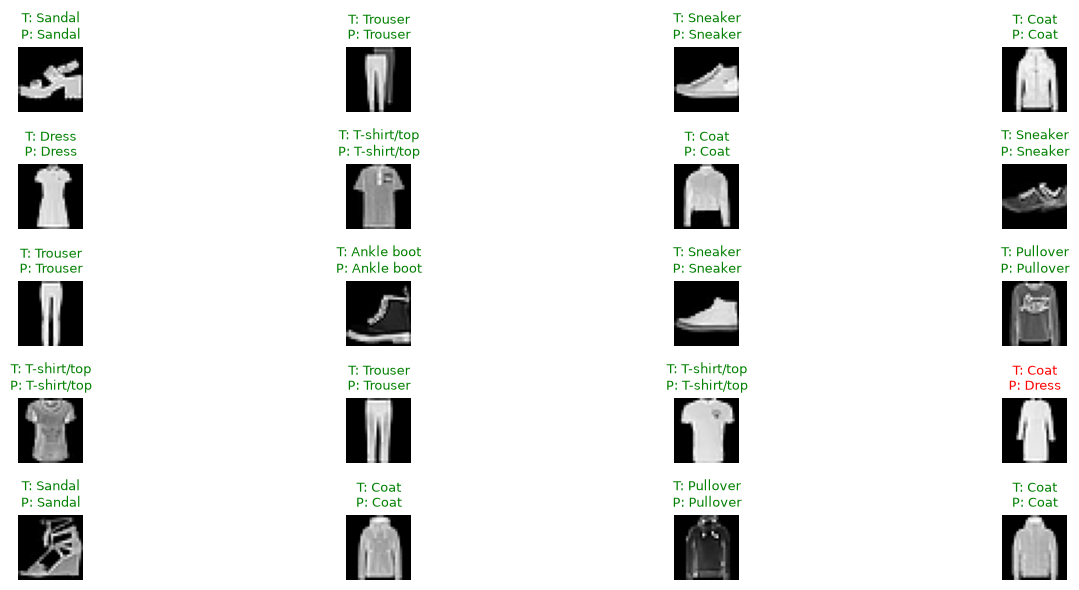

In [10]:
@torch.no_grad()
def predict_random_samples(model, dataset, class_names, num_samples=10):
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    images, true_labels, pred_labels = [], [], []
    for idx in indices:
        img, lbl = dataset[idx]
        pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
        images.append(img)
        true_labels.append(lbl)
        pred_labels.append(pred)

    rows, cols = (2, 5) if num_samples == 10 else (int(np.ceil(np.sqrt(num_samples))), int(np.ceil(num_samples / np.ceil(np.sqrt(num_samples)))))
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        is_correct = true_labels[i] == pred_labels[i]
        color = 'green' if is_correct else 'red'
        plt.title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}", color=color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

predict_random_samples(model, test_set, CLASS_NAMES, num_samples=20)